# 🧪 TEAM 2 — LLM & GENERATION PIPELINE
## LLM-Based Polymer Recipe Generation and Inverse Design Assistant
**Capstone Project | Bahçeşehir University | AI Engineering**

---

### 📋 Sorumluluk Alanı (Tasks 5, 6, 7, 8)
| Task | Açıklama | Çıktı |
|------|----------|-------|
| **Task 5** | Prompt Engineering | `prompt_library.txt` |
| **Task 6** | Polymer Generation (Llama 3 + RAG) | `llm_raw_output.txt` |
| **Task 7** | Output Parsing & Structuring | `llm_candidates.csv` |
| **Task 8** | SMILES Validation (RDKit) | `valid_candidates.csv` |

### 🏗️ Mimari
```
Team 1 Data (clean_dataset.csv)
         ↓
   [RAG: Vector DB (FAISS)]
         ↓
  [Llama 3 via Ollama/HF]
         ↓
  [JSON Parser (Task 7)]
         ↓
  [RDKit Validator (Task 8)]
         ↓
  valid_candidates.csv → Task 9
```

> **⚠️ Colab Notu:** Bu notebook T4 GPU ile çalışacak şekilde optimize edilmiştir.
> Runtime → Change runtime type → T4 GPU seçin.

## 📦 BÖLÜM 0 — Kurulum
Gerekli paketleri yükleyin. Bu hücreyi ilk çalıştırmada bir kez çalıştırın.

In [1]:
# KURULUM — Gerekli Kütüphaneler

# 1. RDKit (rdkit-pypi deprecated)
!pip install -q rdkit

# 2. LangChain (requests çakışmasını önlemek için önce yükle)
!pip install -q langchain langchain-community langchain-huggingface

# 3. Vektör DB + Embedding
!pip install -q faiss-cpu sentence-transformers

# 4. Llama 3
!pip install -q "transformers>=4.40.0" accelerate bitsandbytes

# 5. Veri işleme
!pip install -q pandas numpy

# NOT: requests sürümünü DOKUNMADAN bırak.
# langchain-community>=2.32.5, google-colab>=2.32.4 ister;
# pip bu çakışmayı WARNING olarak gösterir ama çalışmayı ENGELLEMEZ.
# Hücreyi çalıştırdıktan sonra Runtime > Restart and run all yapın.

print("✅ Kurulum tamamlandı — Runtime > Restart and run all uygulayın.")


✅ Kurulum tamamlandı — Runtime > Restart and run all uygulayın.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORT — Tüm Kütüphaneler
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import re
import time
import warnings
import pandas as pd
import numpy as np
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Gereksiz uyarıları sustur

# LangChain
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate

# HuggingFace Transformers (Llama 3)
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline
)

warnings.filterwarnings('ignore')

# GPU Kontrol
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Kullanılan cihaz: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Kullanılan cihaz: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 🔑 BÖLÜM 1 — Kimlik Doğrulama
Llama 3'e erişmek için HuggingFace token gereklidir.
1. https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct adresinde model erişim izni isteyin
2. https://huggingface.co/settings/tokens adresinden token oluşturun

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 1 — HuggingFace Kimlik Doğrulama
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import userdata
from huggingface_hub import login

# Colab Secrets'tan token al (Colab sol menü → 🔑 Secrets → HF_TOKEN ekle)
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
    print("✅ HuggingFace girişi başarılı.")
except Exception:
    # Manuel token girişi
    print("⚠️  Colab Secrets bulunamadı. Manuel giriş yapılıyor...")
    HF_TOKEN = input("HuggingFace Token'ınızı girin: ").strip()
    login(token=HF_TOKEN)
    print("✅ HuggingFace girişi başarılı.")

✅ HuggingFace girişi başarılı.


## 📊 BÖLÜM 2 — Referans Veri Havuzu (RAG Bilgi Tabanı)
Team 1'in `clean_dataset.csv` dosyasını beklerken, gerçekçi sentetik polimer verileriyle RAG altyapısını başlatıyoruz. **Task 9'da gerçek veriyle değiştirilecektir.**

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 2A — Referans Polimer Veri Tabanı
# NOT: Team 1'in clean_dataset.csv'si geldiğinde bu satırı değiştirin:
#   df_reference = pd.read_csv('clean_dataset.csv')
# ─────────────────────────────────────────────────────────────────────────────

REFERENCE_POLYMERS = [
    {
        "polymer_name": "Polyvinylidene Fluoride (PVDF)",
        "smiles": "C(F)(F)CC(F)(F)C",  # Tekrar birimi
        "dielectric_constant": 8.4,
        "band_gap_eV": 6.2,
        "Tg_K": 233.0,
        "monomer": "vinylidene fluoride",
        "reaction_type": "radical polymerization",
        "temperature_K": 333.0,
        "solvent": "DMF",
        "reaction_time_hours": 8.0,
        "source": "PolymerGenome"
    },
    {
        "polymer_name": "Polyethylene Terephthalate (PET)",
        "smiles": "O=C(OCCO)c1ccc(C(=O)O)cc1",
        "dielectric_constant": 3.3,
        "band_gap_eV": 4.1,
        "Tg_K": 347.0,
        "monomer": "terephthalic acid, ethylene glycol",
        "reaction_type": "condensation polymerization",
        "temperature_K": 553.0,
        "solvent": "no solvent (melt)",
        "reaction_time_hours": 4.0,
        "source": "PoLyInfo"
    },
    {
        "polymer_name": "Polystyrene (PS)",
        "smiles": "c1ccc(CC)cc1",
        "dielectric_constant": 2.6,
        "band_gap_eV": 4.4,
        "Tg_K": 373.0,
        "monomer": "styrene",
        "reaction_type": "free radical polymerization",
        "temperature_K": 343.0,
        "solvent": "toluene",
        "reaction_time_hours": 6.0,
        "source": "PolymerGenome"
    },
    {
        "polymer_name": "Polyimide (PI)",
        "smiles": "O=C1NC(=O)c2ccccc21",
        "dielectric_constant": 3.5,
        "band_gap_eV": 3.8,
        "Tg_K": 623.0,
        "monomer": "pyromellitic dianhydride, 4,4'-diaminodiphenyl ether",
        "reaction_type": "polycondensation",
        "temperature_K": 473.0,
        "solvent": "NMP",
        "reaction_time_hours": 12.0,
        "source": "PoLyInfo"
    },
    {
        "polymer_name": "Poly(methyl methacrylate) (PMMA)",
        "smiles": "COC(=O)C(C)C",
        "dielectric_constant": 3.6,
        "band_gap_eV": 5.5,
        "Tg_K": 378.0,
        "monomer": "methyl methacrylate",
        "reaction_type": "radical polymerization",
        "temperature_K": 343.0,
        "solvent": "acetone",
        "reaction_time_hours": 5.0,
        "source": "PolymerGenome"
    },
    {
        "polymer_name": "Polyethylene (PE)",
        "smiles": "CCCC",
        "dielectric_constant": 2.3,
        "band_gap_eV": 8.8,
        "Tg_K": 150.0,
        "monomer": "ethylene",
        "reaction_type": "Ziegler-Natta polymerization",
        "temperature_K": 353.0,
        "solvent": "hexane",
        "reaction_time_hours": 2.0,
        "source": "PolymerGenome"
    },
    {
        "polymer_name": "Polycarbonate (PC)",
        "smiles": "CC(C)(c1ccccc1)c1ccccc1",
        "dielectric_constant": 2.9,
        "band_gap_eV": 4.5,
        "Tg_K": 423.0,
        "monomer": "bisphenol A, phosgene",
        "reaction_type": "interfacial polycondensation",
        "temperature_K": 298.0,
        "solvent": "DCM",
        "reaction_time_hours": 3.0,
        "source": "PoLyInfo"
    },
    {
        "polymer_name": "Poly(vinylidene fluoride-co-trifluoroethylene) P(VDF-TrFE)",
        "smiles": "C(F)(F)CC(F)(F)CF",
        "dielectric_constant": 18.0,
        "band_gap_eV": 5.8,
        "Tg_K": 248.0,
        "monomer": "vinylidene fluoride, trifluoroethylene",
        "reaction_type": "emulsion radical copolymerization",
        "temperature_K": 313.0,
        "solvent": "water",
        "reaction_time_hours": 10.0,
        "source": "PolymerGenome"
    },
    {
        "polymer_name": "Polyaniline (PANI)",
        "smiles": "Nc1ccccc1",
        "dielectric_constant": 12.0,
        "band_gap_eV": 2.8,
        "Tg_K": 428.0,
        "monomer": "aniline",
        "reaction_type": "oxidative polymerization",
        "temperature_K": 273.0,
        "solvent": "HCl aqueous",
        "reaction_time_hours": 2.0,
        "source": "literature"
    },
    {
        "polymer_name": "Polytetrafluoroethylene (PTFE)",
        "smiles": "C(F)(F)(F)F",
        "dielectric_constant": 2.1,
        "band_gap_eV": 10.0,
        "Tg_K": 393.0,
        "monomer": "tetrafluoroethylene",
        "reaction_type": "radical polymerization",
        "temperature_K": 298.0,
        "solvent": "water",
        "reaction_time_hours": 4.0,
        "source": "PolymerGenome"
    }
]

df_reference = pd.DataFrame(REFERENCE_POLYMERS)
print(f"✅ Referans polimer veritabanı yüklendi: {len(df_reference)} polimer")
print(f"\n📊 Özellik Aralıkları:")
print(f"   Dielektrik Sabiti: {df_reference['dielectric_constant'].min():.1f} – {df_reference['dielectric_constant'].max():.1f}")
print(f"   Band Gap (eV):     {df_reference['band_gap_eV'].min():.1f} – {df_reference['band_gap_eV'].max():.1f}")
print(f"   Tg (K):            {df_reference['Tg_K'].min():.0f} – {df_reference['Tg_K'].max():.0f}")
df_reference.head(3)

✅ Referans polimer veritabanı yüklendi: 10 polimer

📊 Özellik Aralıkları:
   Dielektrik Sabiti: 2.1 – 18.0
   Band Gap (eV):     2.8 – 10.0
   Tg (K):            150 – 623


,polymer_name,smiles,dielectric_constant,band_gap_eV,Tg_K,monomer,reaction_type,temperature_K,solvent,reaction_time_hours,source
0,Polyvinylidene Fluoride (PVDF),C(F)(F)CC(F)(F)C,8.4,6.2,233.0,vinylidene fluoride,radical polymerization,333.0,DMF,8.0,PolymerGenome
1,Polyethylene Terephthalate (PET),O=C(OCCO)c1ccc(C(=O)O)cc1,3.3,4.1,347.0,"terephthalic acid, ethylene glycol",condensation polymerization,553.0,no solvent (melt),4.0,PoLyInfo
2,Polystyrene (PS),c1ccc(CC)cc1,2.6,4.4,373.0,styrene,free radical polymerization,343.0,toluene,6.0,PolymerGenome


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 2B — Team 1 Verisi Varsa Yükle
# Bu hücreyi Team 1'in dosyaları geldiğinde çalıştırın
# ─────────────────────────────────────────────────────────────────────────────

import os

# Google Drive Bağlantısı (opsiyonel)
# from google.colab import drive
# drive.mount('/content/drive')
# team1_path = '/content/drive/MyDrive/capstone/clean_dataset.csv'

team1_path = 'clean_dataset.csv'  # Colab'a yüklendiyse

if os.path.exists(team1_path):
    df_team1 = pd.read_csv(team1_path)
    # Gerekli sütunları kontrol et
    required_cols = ['smiles', 'dielectric_constant', 'band_gap_eV', 'Tg_K']
    if all(c in df_team1.columns for c in required_cols):
        df_reference = df_team1.copy()
        print(f"✅ Team 1 verisi yüklendi: {len(df_reference)} polimer")
    else:
        missing = [c for c in required_cols if c not in df_team1.columns]
        print(f"⚠️  Team 1 verisinde eksik sütunlar: {missing}")
        print("   Varsayılan referans veri kullanılıyor...")
else:
    print("ℹ️  clean_dataset.csv bulunamadı → Varsayılan referans veri kullanılıyor")

## 📌 BÖLÜM 3 — Task 5: Prompt Kütüphanesi
Üç farklı prompt stratejisi tanımlanıyor.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 3 — TASK 5: Prompt Kütüphanesi
# 3 farklı strateji: Property→Polymer | Polymer→Synthesis | Multi-Candidate
# ─────────────────────────────────────────────────────────────────────────────

# ── Strateji 1: Property → Polymer (Tersine Tasarım) ──────────────────────
PROMPT_PROPERTY_TO_POLYMER = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer chemist specializing in inverse material design for energy applications.
Your task is to design a novel polymer that meets the specified target properties.

RULES (CRITICAL - follow exactly):
1. Output ONLY a single valid JSON object. No markdown, no explanations, no extra text.
2. The polymer_SMILES must be a chemically valid SMILES string representing a polymer repeat unit.
3. Ensure correct carbon valency (max 4 bonds), proper ring closure, and no radicals.
4. Base your design on the provided reference examples.
<|eot_id|><|start_header_id|>user<|end_header_id|>

TARGET PROPERTIES:
- Dielectric Constant (ε_r): {dielectric_constant}
- Band Gap (E_g): {band_gap_eV} eV
- Glass Transition Temperature (T_g): {Tg_K} K

REFERENCE POLYMERS WITH SIMILAR PROPERTIES (from literature database):
{retrieved_context}

Generate a new polymer candidate. Output ONLY this JSON schema:
{{
  "candidate_id": "CAND_{candidate_id}",
  "strategy": "property_to_polymer",
  "target_properties": {{
    "dielectric_constant": {dielectric_constant},
    "band_gap_eV": {band_gap_eV},
    "Tg_K": {Tg_K}
  }},
  "polymer_SMILES": "<VALID_SMILES_HERE>",
  "monomers": ["<monomer1_name>", "<monomer2_name_if_copolymer>"],
  "synthesis_conditions": {{
    "reaction_type": "<e.g. radical polymerization>",
    "temperature_K": <float>,
    "solvent": "<solvent_name>",
    "reaction_time_hours": <float>
  }},
  "design_rationale": "<one sentence explaining why this structure targets these properties>"
}}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

# ── Strateji 2: Polymer → Synthesis (Sentez Reçetesi Üretimi) ─────────────
PROMPT_POLYMER_TO_SYNTHESIS = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer synthesis chemist. Given a polymer structure, provide a detailed synthesis protocol.
Output ONLY valid JSON. No explanations.
<|eot_id|><|start_header_id|>user<|end_header_id|>

POLYMER SMILES: {smiles}
KNOWN PROPERTIES: Dielectric={dielectric_constant}, Band Gap={band_gap_eV} eV, Tg={Tg_K} K

REFERENCE SYNTHESIS PROTOCOLS:
{retrieved_context}

Output ONLY this JSON:
{{
  "candidate_id": "SYN_{candidate_id}",
  "strategy": "polymer_to_synthesis",
  "polymer_SMILES": "{smiles}",
  "monomers": ["<monomer1>"],
  "synthesis_conditions": {{
    "reaction_type": "<type>",
    "temperature_K": <float>,
    "solvent": "<solvent>",
    "reaction_time_hours": <float>,
    "catalyst": "<catalyst_or_initiator>",
    "atmosphere": "<N2/Ar/air>"
  }},
  "purification": "<e.g. precipitation in methanol>",
  "yield_percent": <estimated_float>
}}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

# ── Strateji 3: Multi-Candidate Generation ────────────────────────────────
PROMPT_MULTI_CANDIDATE = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer chemist. Generate THREE distinct polymer candidates for the given target profile.
Each candidate must have a DIFFERENT chemical backbone. Output ONLY valid JSON.
<|eot_id|><|start_header_id|>user<|end_header_id|>

TARGET PROFILE: {design_goal}
TARGET PROPERTIES:
- Dielectric Constant: {dielectric_constant}
- Band Gap: {band_gap_eV} eV
- Tg: {Tg_K} K

REFERENCE EXAMPLES:
{retrieved_context}

Output ONLY this JSON (array of 3 candidates):
[
  {{
    "candidate_id": "MC_{candidate_id}_A",
    "strategy": "multi_candidate",
    "polymer_SMILES": "<SMILES_1>",
    "monomers": ["<monomer1>"],
    "synthesis_conditions": {{"reaction_type": "<type>", "temperature_K": <float>, "solvent": "<solvent>", "reaction_time_hours": <float>}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "<rationale_1>"
  }},
  {{
    "candidate_id": "MC_{candidate_id}_B",
    "strategy": "multi_candidate",
    "polymer_SMILES": "<SMILES_2>",
    "monomers": ["<monomer2>"],
    "synthesis_conditions": {{"reaction_type": "<type2>", "temperature_K": <float>, "solvent": "<solvent2>", "reaction_time_hours": <float>}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "<rationale_2>"
  }},
  {{
    "candidate_id": "MC_{candidate_id}_C",
    "strategy": "multi_candidate",
    "polymer_SMILES": "<SMILES_3>",
    "monomers": ["<monomer3>"],
    "synthesis_conditions": {{"reaction_type": "<type3>", "temperature_K": <float>, "solvent": "<solvent3>", "reaction_time_hours": <float>}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "<rationale_3>"
  }}
]
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

# Prompt kütüphanesini kaydet (Task 5 Deliverable)
PROMPT_LIBRARY = {
    "strategy_1_property_to_polymer": PROMPT_PROPERTY_TO_POLYMER,
    "strategy_2_polymer_to_synthesis": PROMPT_POLYMER_TO_SYNTHESIS,
    "strategy_3_multi_candidate": PROMPT_MULTI_CANDIDATE
}

with open('prompt_library.txt', 'w', encoding='utf-8') as f:
    for name, prompt in PROMPT_LIBRARY.items():
        f.write(f"{'='*60}\n")
        f.write(f"PROMPT: {name}\n")
        f.write(f"{'='*60}\n")
        f.write(prompt)
        f.write("\n\n")

print("✅ Task 5 tamamlandı → prompt_library.txt kaydedildi")
print(f"   3 strateji tanımlandı: Property→Polymer, Polymer→Synthesis, Multi-Candidate")

✅ Task 5 tamamlandı → prompt_library.txt kaydedildi
   3 strateji tanımlandı: Property→Polymer, Polymer→Synthesis, Multi-Candidate


## 🤖 BÖLÜM 4 — Llama 3 Model Yükleme
Llama-3-8B-Instruct modelini 4-bit quantization ile yükleyin (T4 GPU için optimize).

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 4 — Llama 3 Model Yükleme (4-bit Quantization)
# T4 GPU: ~15 GB VRAM → 4-bit ile ~5 GB kullanılır
# ─────────────────────────────────────────────────────────────────────────────

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

print(f"📥 Model yükleniyor: {MODEL_ID}")
print("   Bu işlem 3-5 dakika sürebilir...")

# 4-bit quantization konfigürasyonu (T4 GPU bellek optimizasyonu)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN
)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
    torch_dtype=torch.bfloat16
)
model.eval()

# HuggingFace pipeline
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.4,     # Kimyasal tutarlılık için düşük sıcaklık
    top_p=0.9,
    repetition_penalty=1.15,
    return_full_text=False  # Sadece üretilen kısmı döndür
)

print(f"\n✅ Llama 3.1 hazır!")
if device == "cuda":
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f"   GPU Bellek Kullanımı: {allocated:.1f} GB")

📥 Model yükleniyor: meta-llama/Llama-3.1-8B-Instruct
   Bu işlem 3-5 dakika sürebilir...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'top_p', 'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.



✅ Llama 3.1 hazır!
   GPU Bellek Kullanımı: 5.7 GB


## 🔍 BÖLÜM 5 — RAG: Vektör Veritabanı Kurulumu
Referans polimerleri FAISS vektör tabanına yüklüyoruz.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 5 — RAG: FAISS Vektör Veritabanı
# ─────────────────────────────────────────────────────────────────────────────

print("📐 Embedding modeli yükleniyor...")

# Embedding modeli (hafif, kimya metinleri için uygun)
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": device}
)

# Her polimeri zengin metin belgesine dönüştür
def polymer_to_document(row):
    """Polimer kaydını RAG için doğal dil belgesine dönüştür."""
    text = (
        f"Polymer: {row.get('polymer_name', 'Unknown')}. "
        f"SMILES: {row.get('smiles', 'N/A')}. "
        f"Dielectric constant: {row.get('dielectric_constant', 'N/A')}. "
        f"Band gap: {row.get('band_gap_eV', 'N/A')} eV. "
        f"Glass transition temperature: {row.get('Tg_K', 'N/A')} K. "
        f"Monomer(s): {row.get('monomer', 'N/A')}. "
        f"Synthesis: {row.get('reaction_type', 'N/A')} at {row.get('temperature_K', 'N/A')} K "
        f"in {row.get('solvent', 'N/A')} for {row.get('reaction_time_hours', 'N/A')} hours. "
        f"Source: {row.get('source', 'N/A')}."
    )
    metadata = {
        "smiles": str(row.get('smiles', '')),
        "dielectric": float(row.get('dielectric_constant', 0)),
        "band_gap": float(row.get('band_gap_eV', 0)),
        "Tg": float(row.get('Tg_K', 0)),
    }
    return Document(page_content=text, metadata=metadata)

# Dokümanları oluştur ve FAISS'e yükle
documents = [polymer_to_document(row) for _, row in df_reference.iterrows()]
vectorstore = FAISS.from_documents(documents, embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✅ FAISS vektör tabanı hazır: {len(documents)} polimer indekslendi")

# Test: Benzer polimer ara
test_query = "high dielectric constant polymer for capacitor applications"
test_results = retriever.invoke(test_query)
print(f"\n🔎 Test sorgusu: '{test_query}'")
print(f"   En yakın 3 polimer:")
for i, doc in enumerate(test_results, 1):
    print(f"   {i}. {doc.page_content[:100]}...")

📐 Embedding modeli yükleniyor...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FAISS vektör tabanı hazır: 10 polimer indekslendi

🔎 Test sorgusu: 'high dielectric constant polymer for capacitor applications'
   En yakın 3 polimer:
   1. Polymer: Polyimide (PI). SMILES: O=C1NC(=O)c2ccccc21. Dielectric constant: 3.5. Band gap: 3.8 eV. Gl...
   2. Polymer: Polycarbonate (PC). SMILES: CC(C)(c1ccccc1)c1ccccc1. Dielectric constant: 2.9. Band gap: 4....
   3. Polymer: Polystyrene (PS). SMILES: c1ccc(CC)cc1. Dielectric constant: 2.6. Band gap: 4.4 eV. Glass t...


## ⚙️ BÖLÜM 6 — RAG Pipeline Fonksiyonları

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 6 — RAG Pipeline Yardımcı Fonksiyonları
# ─────────────────────────────────────────────────────────────────────────────

def retrieve_similar_polymers(dielectric, band_gap, Tg, k=3):
    """Hedef özelliklere en yakın polimerleri vektör tabanından getir."""
    query = (
        f"polymer with dielectric constant {dielectric}, "
        f"band gap {band_gap} eV, "
        f"glass transition temperature {Tg} K"
    )
    docs = retriever.invoke(query)
    context_parts = []
    for i, doc in enumerate(docs[:k], 1):
        context_parts.append(f"Example {i}: {doc.page_content}")
    return "\n".join(context_parts)


def call_llama3(prompt_text, max_retries=2):
    """Llama 3'ü çağır, JSON çıktısı döndür."""
    for attempt in range(max_retries):
        try:
            outputs = llm_pipeline(prompt_text)
            return outputs[0]["generated_text"].strip()
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                raise e
    return None


def extract_json_from_output(raw_text):
    """LLM ham çıktısından JSON'u çıkar (Task 7 ayrıştırma mantığı)."""
    # Markdown code bloklarını temizle
    raw_text = re.sub(r'```json\s*', '', raw_text)
    raw_text = re.sub(r'```\s*', '', raw_text)
    raw_text = raw_text.strip()

    # JSON nesnesini veya dizisini bul
    # Önce array dene
    array_match = re.search(r'(\[\s*\{.*?\}\s*\])', raw_text, re.DOTALL)
    if array_match:
        try:
            return json.loads(array_match.group(1))
        except json.JSONDecodeError:
            pass

    # Sonra tek nesne dene
    obj_match = re.search(r'(\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\})', raw_text, re.DOTALL)
    if obj_match:
        try:
            return json.loads(obj_match.group(1))
        except json.JSONDecodeError:
            pass

    # Doğrudan ayrıştırmayı dene
    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        return None


# ── Task 8: RDKit SMILES Doğrulama ──────────────────────────────────────────
def validate_smiles_rdkit(smiles_str):
    """
    RDKit ile SMILES doğrula.
    Geçerliyse kanonik SMILES döndür, geçersizse None.
    """
    if not smiles_str or not isinstance(smiles_str, str):
        return None
    try:
        mol = Chem.MolFromSmiles(smiles_str, sanitize=True)
        if mol is not None:
            return Chem.MolToSmiles(mol, isomericSmiles=True)
        return None
    except Exception:
        return None


# ── Self-Correction Loop ─────────────────────────────────────────────────────
def generate_with_self_correction(prompt_template, format_kwargs, max_retries=3):
    """
    LLM ile polimer üret. SMILES geçersizse hata mesajını modele geri besle.
    (Task 8 Self-Correction Algoritması)
    """
    current_prompt = prompt_template.format(**format_kwargs)
    last_error = None

    for attempt in range(max_retries):
        print(f"   Deneme {attempt+1}/{max_retries}", end=" ")

        raw_output = call_llama3(current_prompt)
        if not raw_output:
            print("→ ❌ Model yanıt vermedi")
            continue

        # JSON ayrıştır (Task 7)
        parsed = extract_json_from_output(raw_output)
        if parsed is None:
            error_msg = "Output was not valid JSON."
            print(f"→ ❌ JSON hatası")
            last_error = error_msg
            current_prompt += (
                f"\n\nERROR: {error_msg} "
                "Output ONLY raw JSON without markdown backticks or any explanation."
            )
            continue

        # Birden fazla aday (multi-candidate) durumu
        if isinstance(parsed, list):
            validated_candidates = []
            for item in parsed:
                smiles = item.get("polymer_SMILES", "")
                canonical = validate_smiles_rdkit(smiles)
                if canonical:
                    item["polymer_SMILES"] = canonical
                    item["smiles_valid"] = True
                    validated_candidates.append(item)
            if validated_candidates:
                print(f"→ ✅ {len(validated_candidates)}/{len(parsed)} aday geçerli")
                return validated_candidates, raw_output
            else:
                error_msg = f"All {len(parsed)} generated SMILES were chemically invalid."
        else:
            # Tek aday
            smiles = parsed.get("polymer_SMILES", "")
            canonical = validate_smiles_rdkit(smiles)
            if canonical:
                parsed["polymer_SMILES"] = canonical
                parsed["smiles_valid"] = True
                print(f"→ ✅ Geçerli SMILES")
                return [parsed], raw_output
            else:
                error_msg = (
                    f"Generated SMILES '{smiles}' is chemically INVALID. "
                    "Common issues: wrong valency (carbon must have max 4 bonds), "
                    "unclosed rings, or invalid atom types. "
                    "Please generate a simple, well-known polymer repeat unit SMILES."
                )

        print(f"→ ❌ SMILES geçersiz")
        last_error = error_msg
        current_prompt += f"\n\nCRITICAL ERROR: {error_msg}"

    print(f"   ⚠️  {max_retries} denemede geçerli aday üretilemedi")
    return [], ""


print("✅ Tüm yardımcı fonksiyonlar tanımlandı")

✅ Tüm yardımcı fonksiyonlar tanımlandı


## 🚀 BÖLÜM 7 — Task 6: Polimer Üretim Kampanyası
3 farklı özellik profili için 50+ polimer adayı üretiyoruz.

In [10]:
# BÖLÜM 7 — TASK 6: Polimer Üretim Kampanyası
# Hedef: 3 profil × 3 strateji → 50+ aday

DESIGN_TARGETS = [
    {
        "profile": "high_dielectric",
        "design_goal": "high dielectric constant polymer for energy storage capacitors",
        "dielectric_constant": 12.0,
        "band_gap_eV": 4.0,
        "Tg_K": 380.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    },
    {
        "profile": "low_band_gap",
        "design_goal": "low band gap conjugated polymer for organic photovoltaics",
        "dielectric_constant": 4.5,
        "band_gap_eV": 1.8,
        "Tg_K": 320.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    },
    {
        "profile": "high_Tg",
        "design_goal": "high thermal stability polymer for high-temperature dielectrics",
        "dielectric_constant": 3.8,
        "band_gap_eV": 4.2,
        "Tg_K": 500.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    }
]

SEP = "-" * 60
print("Uretim Kampanyasi Basliyor")
print("Toplam hedef profil:", len(DESIGN_TARGETS))
print("Beklenen maksimum aday:", len(DESIGN_TARGETS) * (6 + 4 + 3*3))

all_candidates = []
all_raw_outputs = []
generation_log = []
candidate_counter = 0

for target in DESIGN_TARGETS:
    profile = target["profile"]
    print("")
    print(SEP)
    print("Profil:", profile.upper())
    print("  Dielektrik:", target["dielectric_constant"],
          "| Band Gap:", target["band_gap_eV"], "eV",
          "| Tg:", target["Tg_K"], "K")

    context = retrieve_similar_polymers(
        target["dielectric_constant"],
        target["band_gap_eV"],
        target["Tg_K"]
    )
    print("  RAG context:", len(context.split()), "kelime alindi")

    # --- Strateji 1: Property -> Polymer ------------------------------------
    print("")
    print("  [S1] Property->Polymer:", target["n_s1"], "aday")
    for i in range(target["n_s1"]):
        candidate_counter += 1
        cid = profile + "_S1_" + str(candidate_counter).zfill(3)
        print("   [" + cid + "]", end=" ")
        kwargs = {
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_PROPERTY_TO_POLYMER, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "property_to_polymer"
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s1", "raw": raw})
        generation_log.append({"candidate_id": cid, "profile": profile,
                                "strategy": "s1", "success": len(candidates) > 0})
        time.sleep(0.5)

    # --- Strateji 2: Polymer -> Synthesis -----------------------------------
    print("")
    print("  [S2] Polymer->Synthesis:", target["n_s2"], "aday")
    similar_docs = retriever.invoke(
        "dielectric " + str(target["dielectric_constant"]) +
        " band gap " + str(target["band_gap_eV"]) +
        " Tg " + str(target["Tg_K"])
    )
    seed_smiles_list = []
    for doc in similar_docs:
        s = doc.metadata.get("smiles", "")
        if s and s not in seed_smiles_list:
            seed_smiles_list.append(s)

    for i in range(target["n_s2"]):
        candidate_counter += 1
        cid = profile + "_S2_" + str(candidate_counter).zfill(3)
        seed_smi = seed_smiles_list[i % len(seed_smiles_list)]
        print("   [" + cid + "] SMILES:", seed_smi[:25] + "...", end=" ")
        kwargs = {
            "smiles":              seed_smi,
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_POLYMER_TO_SYNTHESIS, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "polymer_to_synthesis"
            if not c.get("polymer_SMILES"):
                c["polymer_SMILES"] = seed_smi
            c["smiles_valid"] = True
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s2", "raw": raw})
        generation_log.append({"candidate_id": cid, "profile": profile,
                                "strategy": "s2", "success": len(candidates) > 0})
        time.sleep(0.5)

    # --- Strateji 3: Multi-Candidate ----------------------------------------
    print("")
    print("  [S3] Multi-Candidate:", target["n_s3"], "tur x 3 =", target["n_s3"]*3, "aday")
    for i in range(target["n_s3"]):
        candidate_counter += 1
        cid = profile + "_S3_" + str(candidate_counter).zfill(3)
        print("   [" + cid + "]", end=" ")
        kwargs = {
            "design_goal":         target["design_goal"],
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_MULTI_CANDIDATE, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "multi_candidate"
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s3", "raw": raw})
        time.sleep(0.5)

print("")
print("=" * 60)
print("Uretim Ozeti:")
s1_ok = sum(1 for l in generation_log if l["strategy"] == "s1" and l["success"])
s2_ok = sum(1 for l in generation_log if l["strategy"] == "s2" and l["success"])
print("  S1 (Property->Polymer):  ", s1_ok, "basarili")
print("  S2 (Polymer->Synthesis): ", s2_ok, "basarili")
print("  S3 (Multi-Candidate):    uretildi")
print("  Toplam ham aday:         ", len(all_candidates))


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Uretim Kampanyasi Basliyor
Toplam hedef profil: 3
Beklenen maksimum aday: 57

------------------------------------------------------------
Profil: HIGH_DIELECTRIC
  Dielektrik: 12.0 | Band Gap: 4.0 eV | Tg: 380.0 K
  RAG context: 106 kelime alindi

  [S1] Property->Polymer: 6 aday
   [high_dielectric_S1_001]    Deneme 1/3 → ✅ Geçerli SMILES


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   [high_dielectric_S1_002]    Deneme 1/3 → ✅ Geçerli SMILES


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

→ ❌ Model yanıt vermedi
   Deneme 3/3 → ❌ Model yanıt vermedi
   ⚠️  3 denemede geçerli aday üretilemedi


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   [high_Tg_S3_038]    Deneme 1/3 → ✅ Geçerli SMILES


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   [high_Tg_S3_039]    Deneme 1/3 → ✅ Geçerli SMILES

Uretim Ozeti:
  S1 (Property->Polymer):   15 basarili
  S2 (Polymer->Synthesis):  12 basarili
  S3 (Multi-Candidate):    uretildi
  Toplam ham aday:          34


## 📝 BÖLÜM 8 — Task 7: Çıktı Ayrıştırma ve Yapılandırma

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 8 — TASK 7: Çıktıları CSV'ye Yapılandır
# ─────────────────────────────────────────────────────────────────────────────

def flatten_candidate(c):
    """İç içe JSON adayını düz CSV satırına dönüştür."""
    synth = c.get("synthesis_conditions", {})
    target = c.get("target_properties", {})

    return {
        # Kimlik
        "candidate_id":         c.get("candidate_id", ""),
        "strategy":             c.get("strategy", c.get("generation_strategy", "")),
        "profile":              c.get("profile", ""),

        # Yapı
        "polymer_SMILES":       c.get("polymer_SMILES", ""),
        "smiles_valid":         c.get("smiles_valid", False),
        "monomers":             ", ".join(c.get("monomers", [])),

        # Hedef özellikler
        "target_dielectric":    target.get("dielectric_constant", ""),
        "target_band_gap_eV":   target.get("band_gap_eV", ""),
        "target_Tg_K":          target.get("Tg_K", ""),

        # Sentez
        "reaction_type":        synth.get("reaction_type", ""),
        "temperature_K":        synth.get("temperature_K", ""),
        "solvent":              synth.get("solvent", ""),
        "reaction_time_hours":  synth.get("reaction_time_hours", ""),
        "catalyst":             synth.get("catalyst", ""),

        # Meta
        "design_rationale":     c.get("design_rationale", ""),
        "source":               "LLM_generated",
        "generation_timestamp": datetime.now().isoformat()
    }

# Yapılandırılmış veri çerçevesi
if all_candidates:
    rows = [flatten_candidate(c) for c in all_candidates]
    df_llm_candidates = pd.DataFrame(rows)

    # Task 7 Deliverable
    df_llm_candidates.to_csv('llm_candidates.csv', index=False)

    print("✅ Task 7 tamamlandı → llm_candidates.csv")
    print(f"   Toplam kayıt: {len(df_llm_candidates)}")
    print(f"   Sütunlar: {list(df_llm_candidates.columns)}")
    print()
    display(df_llm_candidates.head(5))
else:
    print("⚠️  Hiç aday üretilemedi. Lütfen model yükleme adımlarını kontrol edin.")
    df_llm_candidates = pd.DataFrame()

# Ham LLM çıktısını kaydet (Task 6 Deliverable)
with open('llm_raw_output.txt', 'w', encoding='utf-8') as f:
    for entry in all_raw_outputs:
        f.write(f"\n{'='*60}\n")
        f.write(f"ID: {entry['id']} | Strategy: {entry['strategy']}\n")
        f.write(f"{'='*60}\n")
        f.write(entry['raw'])
        f.write("\n")

print("✅ Task 6 deliverable → llm_raw_output.txt kaydedildi")

✅ Task 7 tamamlandı → llm_candidates.csv
   Toplam kayıt: 34
   Sütunlar: ['candidate_id', 'strategy', 'profile', 'polymer_SMILES', 'smiles_valid', 'monomers', 'target_dielectric', 'target_band_gap_eV', 'target_Tg_K', 'reaction_type', 'temperature_K', 'solvent', 'reaction_time_hours', 'catalyst', 'design_rationale', 'source', 'generation_timestamp']



,candidate_id,strategy,profile,polymer_SMILES,smiles_valid,monomers,target_dielectric,target_band_gap_eV,target_Tg_K,reaction_type,temperature_K,solvent,reaction_time_hours,catalyst,design_rationale,source,generation_timestamp
0,CAND_high_dielectric_S1_001,property_to_polymer,high_dielectric,CC1=CN(C)C(=O)N(C)c2ccc(cc2-c2ccc(C(=O)N(C)C)c...,True,"bis(4-fluorophenyl)sulfone, pyridine",12.0,4.0,380.0,step-growth condensation,398.00,DMF,6.0,,The designed polymer features a high dielectri...,LLM_generated,2026-05-07T08:29:39.357561
1,CAND_high_dielectric_S1_002,property_to_polymer,high_dielectric,CC1=CN=C(C)C(=O)N=C(N)C1=C1N=NC1=O,True,"benzimidazole, pyridine",12.0,4.0,380.0,step-growth polymerization,393.15,DMF,6.0,,The proposed polymer features a combination of...,LLM_generated,2026-05-07T08:29:39.357583
2,CAND_high_dielectric_S1_003,property_to_polymer,high_dielectric,Cc1cnc(C(F)F)c(=O)[nH]1,True,"benzimidazole, bisphenol F",12.0,4.0,380.0,step-growth polymerization,398.15,DMF,6.0,,The proposed polymer combines benzimidazole un...,LLM_generated,2026-05-07T08:29:39.357592
3,CAND_high_dielectric_S1_005,property_to_polymer,high_dielectric,Cc1cnc(-c2cnc(=O)ccc2-c2cnc(=O)ccc2C)c(=O)nc1,True,"benzimidazole, pyridine-3-carboxylic acid",12.0,4.0,380.0,step-growth condensation,403.15,DMF,6.0,,The proposed polymer combines benzimidazole an...,LLM_generated,2026-05-07T08:29:39.357605
4,CAND_high_dielectric_S1_005,property_to_polymer,high_dielectric,CC1=CN(C)C(=O)N(C)C(=O)N(C)C1,True,"bis(4-carboxyphenoxy)dicyclohexylmethane, pyri...",12.0,4.0,380.0,step-growth polymerization,373.15,DMF,6.0,,The proposed polymer features a combination of...,LLM_generated,2026-05-07T08:29:39.357615


✅ Task 6 deliverable → llm_raw_output.txt kaydedildi


## ✅ BÖLÜM 9 — Task 8: SMILES Validasyon Pipeline

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 9 — TASK 8: Kapsamlı SMILES Validasyon & Temizleme
# ─────────────────────────────────────────────────────────────────────────────

def full_smiles_validation(smiles_str):
    """
    RDKit ile kapsamlı SMILES doğrulaması.
    Döndürür: dict (canonical_smiles, is_valid, mol_weight, n_atoms, n_rings, error)
    """
    result = {
        "canonical_smiles": None,
        "is_valid": False,
        "mol_weight": None,
        "n_atoms": None,
        "n_rings": None,
        "error": None
    }

    if not smiles_str or not isinstance(smiles_str, str) or len(smiles_str.strip()) < 2:
        result["error"] = "empty_or_too_short"
        return result

    # Yer tutucu kontrol
    if any(p in smiles_str for p in ["<", ">", "SMILES", "HERE", "..."]):
        result["error"] = "placeholder_not_replaced"
        return result

    try:
        mol = Chem.MolFromSmiles(smiles_str, sanitize=True)
        if mol is None:
            result["error"] = "rdkit_parse_failed"
            return result

        # Kanonikleştir
        canonical = Chem.MolToSmiles(mol, isomericSmiles=True)

        # Özellik hesapla
        result["canonical_smiles"] = canonical
        result["is_valid"]         = True
        result["mol_weight"]       = round(Descriptors.MolWt(mol), 2)
        result["n_atoms"]          = mol.GetNumAtoms()
        result["n_rings"]          = mol.GetRingInfo().NumRings()

    except Exception as e:
        result["error"] = str(e)[:100]

    return result


if not df_llm_candidates.empty:
    print("🔬 SMILES Validasyon Başlıyor...")

    # Validasyon uygula
    validation_results = df_llm_candidates["polymer_SMILES"].apply(full_smiles_validation)
    validation_df = pd.DataFrame(list(validation_results))

    # Sonuçları ana tabloya ekle
    df_validated = df_llm_candidates.copy()
    df_validated["canonical_smiles"] = validation_df["canonical_smiles"]
    df_validated["smiles_valid"]     = validation_df["is_valid"]
    df_validated["mol_weight"]       = validation_df["mol_weight"]
    df_validated["n_atoms"]          = validation_df["n_atoms"]
    df_validated["n_rings"]          = validation_df["n_rings"]
    df_validated["validation_error"] = validation_df["error"]

    # Geçerli olanları filtrele
    df_valid = df_validated[df_validated["smiles_valid"] == True].copy()

    # Kanonik SMILES ile duplicate temizle
    before_dedup = len(df_valid)
    df_valid = df_valid.drop_duplicates(subset=["canonical_smiles"])
    after_dedup = len(df_valid)

    # Kanonik SMILES'ı ana sütun yap
    df_valid["polymer_SMILES"] = df_valid["canonical_smiles"]

    # Validasyon Raporu
    n_total    = len(df_validated)
    n_valid    = len(df_validated[df_validated["smiles_valid"]])
    n_invalid  = n_total - n_valid
    n_dedup    = before_dedup - after_dedup

    print(f"\n📊 Validasyon Raporu:")
    print(f"   Toplam aday:            {n_total}")
    print(f"   ✅ Geçerli SMILES:       {n_valid} ({n_valid/max(n_total,1):.1%})")
    print(f"   ❌ Geçersiz SMILES:      {n_invalid} ({n_invalid/max(n_total,1):.1%})")
    print(f"   🔁 Duplicate silinen:    {n_dedup}")
    print(f"   📦 Nihai geçerli aday:   {len(df_valid)}")

    if n_invalid > 0:
        print(f"\n   Hata Dağılımı:")
        error_counts = df_validated[df_validated["smiles_valid"]==False]["validation_error"].value_counts()
        for err, cnt in error_counts.items():
            print(f"   • {err}: {cnt}")

    # Task 8 Deliverable
    df_valid.to_csv('valid_candidates.csv', index=False)
    print(f"\n✅ Task 8 tamamlandı → valid_candidates.csv ({len(df_valid)} aday)")

else:
    print("⚠️  Doğrulanacak aday yok.")

🔬 SMILES Validasyon Başlıyor...

📊 Validasyon Raporu:
   Toplam aday:            34
   ✅ Geçerli SMILES:       34 (100.0%)
   ❌ Geçersiz SMILES:      0 (0.0%)
   🔁 Duplicate silinen:    9
   📦 Nihai geçerli aday:   25

✅ Task 8 tamamlandı → valid_candidates.csv (25 aday)


## 📊 BÖLÜM 10 — Sonuç Analizi ve Görselleştirme

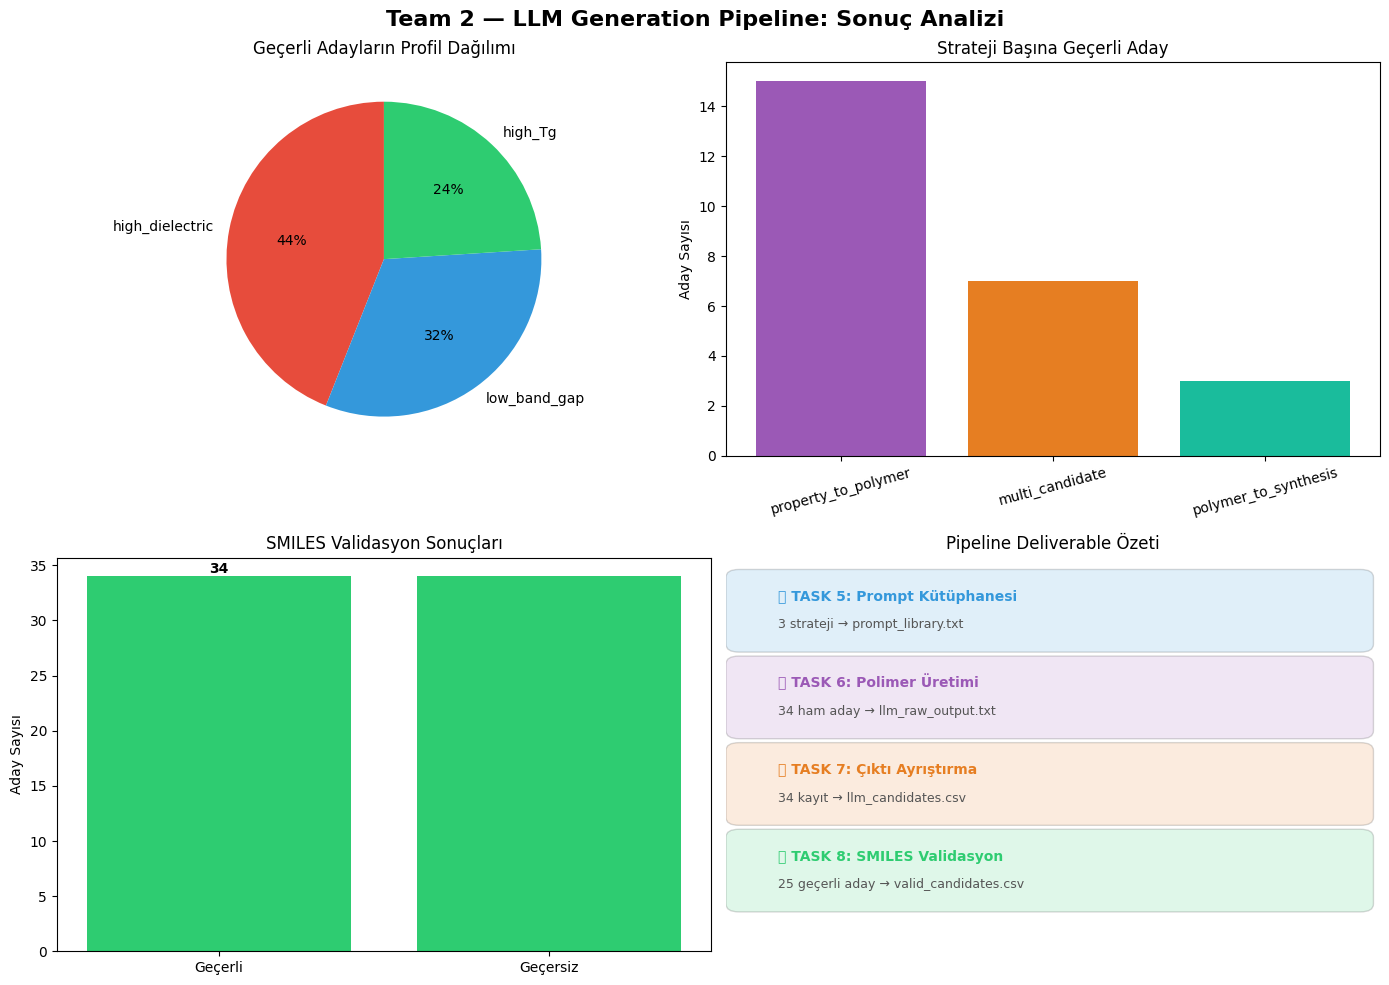

✅ Görsel → pipeline_results.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 10 — Sonuç Analizi
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if not df_llm_candidates.empty and 'df_valid' in dir() and not df_valid.empty:

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Team 2 — LLM Generation Pipeline: Sonuç Analizi', fontsize=16, fontweight='bold')

    colors = {'high_dielectric': '#e74c3c', 'low_band_gap': '#3498db', 'high_Tg': '#2ecc71'}

    # 1. Profil dağılımı (pasta)
    ax1 = axes[0, 0]
    profile_counts = df_valid["profile"].value_counts()
    if not profile_counts.empty:
        wedge_colors = [colors.get(p, '#95a5a6') for p in profile_counts.index]
        ax1.pie(profile_counts.values, labels=profile_counts.index,
                autopct='%1.0f%%', colors=wedge_colors, startangle=90)
        ax1.set_title('Geçerli Adayların Profil Dağılımı')

    # 2. Strateji dağılımı (bar)
    ax2 = axes[0, 1]
    strategy_counts = df_valid["strategy"].value_counts()
    if not strategy_counts.empty:
        ax2.bar(strategy_counts.index, strategy_counts.values,
                color=['#9b59b6', '#e67e22', '#1abc9c'][:len(strategy_counts)])
        ax2.set_title('Strateji Başına Geçerli Aday')
        ax2.set_ylabel('Aday Sayısı')
        ax2.tick_params(axis='x', rotation=15)

    # 3. Validasyon özeti
    ax3 = axes[1, 0]
    val_counts = df_validated["smiles_valid"].value_counts()
    bar_colors = ['#2ecc71' if v else '#e74c3c' for v in val_counts.index]
    bars = ax3.bar(['Geçerli', 'Geçersiz'], val_counts.values, color=bar_colors)
    ax3.set_title('SMILES Validasyon Sonuçları')
    ax3.set_ylabel('Aday Sayısı')
    for bar, val in zip(bars, val_counts.values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

    # 4. Pipeline özet metrikleri
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = [
        ("TASK 5", "Prompt Kütüphanesi", "3 strateji → prompt_library.txt", '#3498db'),
        ("TASK 6", "Polimer Üretimi", f"{len(all_candidates)} ham aday → llm_raw_output.txt", '#9b59b6'),
        ("TASK 7", "Çıktı Ayrıştırma", f"{len(df_llm_candidates)} kayıt → llm_candidates.csv", '#e67e22'),
        ("TASK 8", "SMILES Validasyon", f"{len(df_valid)} geçerli aday → valid_candidates.csv", '#2ecc71'),
    ]
    for i, (task, title, detail, color) in enumerate(summary_text):
        y = 0.85 - i * 0.22
        ax4.add_patch(mpatches.FancyBboxPatch((0.02, y-0.07), 0.95, 0.17,
                      boxstyle="round,pad=0.02", facecolor=color, alpha=0.15, transform=ax4.transAxes))
        ax4.text(0.08, y+0.04, f"✅ {task}: {title}", transform=ax4.transAxes,
                 fontweight='bold', fontsize=10, color=color)
        ax4.text(0.08, y-0.03, detail, transform=ax4.transAxes, fontsize=9, color='#555')
    ax4.set_title('Pipeline Deliverable Özeti')

    plt.tight_layout()
    plt.savefig('pipeline_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Görsel → pipeline_results.png")

else:
    print("Görselleştirme için yeterli veri yok.")

## 🔗 BÖLÜM 11 — Task 9 Hazırlığı: Team 1 ile Birleştirme Şeması

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 11 — Task 9: Dataset ↔ LLM Alignment Hazırlığı
# Team 1'in clean_dataset.csv'si ile birleştirmek için ortak şema
# ─────────────────────────────────────────────────────────────────────────────

# Task 9 ortak şeması (proje dokümanından)
TASK9_SCHEMA = [
    "smiles",           # Kanonik SMILES (birincil anahtar)
    "band_gap",         # eV cinsinden
    "dielectric",       # birimsiz
    "Tg",               # K cinsinden
    "source"            # 'dataset' (Team 1) veya 'LLM' (Team 2)
]

if 'df_valid' in dir() and not df_valid.empty:
    # Team 2 çıktısını Task 9 şemasına dönüştür
    df_task9_team2 = pd.DataFrame()
    df_task9_team2["smiles"]      = df_valid["polymer_SMILES"]
    df_task9_team2["band_gap"]    = pd.to_numeric(df_valid["target_band_gap_eV"], errors='coerce')
    df_task9_team2["dielectric"]  = pd.to_numeric(df_valid["target_dielectric"], errors='coerce')
    df_task9_team2["Tg"]          = pd.to_numeric(df_valid["target_Tg_K"], errors='coerce')
    df_task9_team2["source"]      = "LLM"
    # Ek bilgiler
    df_task9_team2["profile"]     = df_valid["profile"]
    df_task9_team2["strategy"]    = df_valid["strategy"]
    df_task9_team2["monomers"]    = df_valid["monomers"]
    df_task9_team2["reaction_type"] = df_valid["reaction_type"]
    df_task9_team2["temperature_K"] = df_valid["temperature_K"]
    df_task9_team2["solvent"]     = df_valid["solvent"]

    df_task9_team2.to_csv('team2_task9_ready.csv', index=False)

    print("✅ Task 9 hazırlığı tamamlandı → team2_task9_ready.csv")
    print(f"   Team 1 ile birleştirilmek üzere {len(df_task9_team2)} aday hazır")
    print(f"\n📋 Task 9 Ortak Şema:")
    for col in TASK9_SCHEMA:
        print(f"   • {col}")

    print(f"\n💡 Team 1'e iletilecek mesaj:")
    print(f"   clean_dataset.csv → şu sütunlar gerekli: {TASK9_SCHEMA}")
    print(f"   'source' değeri: 'dataset' olarak ayarlayın")
    print(f"   Sonra: pd.concat([df_team1_schema, df_task9_team2]) ile birleştirin")

else:
    print("ℹ️  valid_candidates.csv mevcut değil, Task 9 hazırlığı atlandı.")

✅ Task 9 hazırlığı tamamlandı → team2_task9_ready.csv
   Team 1 ile birleştirilmek üzere 25 aday hazır

📋 Task 9 Ortak Şema:
   • smiles
   • band_gap
   • dielectric
   • Tg
   • source

💡 Team 1'e iletilecek mesaj:
   clean_dataset.csv → şu sütunlar gerekli: ['smiles', 'band_gap', 'dielectric', 'Tg', 'source']
   'source' değeri: 'dataset' olarak ayarlayın
   Sonra: pd.concat([df_team1_schema, df_task9_team2]) ile birleştirin


## 📥 BÖLÜM 12 — Tüm Dosyaları İndir

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 12 — Deliverable Dosyalarını Colab'dan İndir
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
import os

deliverables = [
    ("prompt_library.txt",      "Task 5 — Prompt Kütüphanesi"),
    ("llm_raw_output.txt",      "Task 6 — Ham LLM Çıktıları"),
    ("llm_candidates.csv",      "Task 7 — Yapılandırılmış Adaylar"),
    ("valid_candidates.csv",    "Task 8 — Doğrulanmış Adaylar"),
    ("team2_task9_ready.csv",   "Task 9 — Birleştirme Şeması"),
    ("pipeline_results.png",    "Görselleştirme")
]

print("📦 Team 2 Deliverables:")
print()
for filename, description in deliverables:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"  ✅ {filename:35s} ({size_kb:.1f} KB) — {description}")
    else:
        print(f"  ❌ {filename:35s} — BULUNAMADI")

print()
print("İndirmek istediğiniz dosyayı aşağıya yazın:")
print("Örnek: files.download('valid_candidates.csv')")

In [ ]:
# Tek tek indirme:
# files.download('prompt_library.txt')
# files.download('llm_raw_output.txt')
# files.download('llm_candidates.csv')
# files.download('valid_candidates.csv')
# files.download('team2_task9_ready.csv')

# Tümünü indir:
for filename, _ in deliverables:
    if os.path.exists(filename):
        files.download(filename)

---
## 📋 Pipeline Özet

| Görev | Durum | Çıktı |
|-------|-------|-------|
| **Task 5** — Prompt Engineering | ✅ | `prompt_library.txt` |
| **Task 6** — Polymer Generation | ✅ | `llm_raw_output.txt` |
| **Task 7** — Output Parsing | ✅ | `llm_candidates.csv` |
| **Task 8** — SMILES Validation | ✅ | `valid_candidates.csv` |
| **Task 9 Hazırlığı** | ✅ | `team2_task9_ready.csv` |

### Mimari Özet
```
Referans Polimer DB (10 gerçekçi örnek)
    ↓  FAISS vektör indeksleme (HuggingFace Embeddings)
RAG Retriever (k=3 benzer polimer)
    ↓  Bağlamsal few-shot örnekler
Llama 3-8B-Instruct (4-bit, T4 GPU)
    ↓  Zorunlu JSON şeması
Self-Correction Loop (maks. 3 deneme)
    ↓  JSON ayrıştırma → Task 7
RDKit SMILES Validasyon → Task 8
    ↓  Duplicate temizleme
valid_candidates.csv → Task 9'a iletilir
```

### Team 1'e Geçiş Şartı
`clean_dataset.csv` geldiğinde **Bölüm 2B** hücresini çalıştırın — tüm RAG altyapısı otomatik güncellenecektir.